## Cell 1 — Install & Import Libraries

In [6]:

import subprocess, sys

libs = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'wordcloud']
for lib in libs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', lib, '-q'], check=False)

print('All libraries ready!')

All libraries ready!


In [7]:

import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']   = (12, 5)
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.3
plt.rcParams['font.size']        = 12

OUTPUT_DIR = 'outputs/eda'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(' Imports done')
print(f' Charts will save to: {os.path.abspath(OUTPUT_DIR)}')

 Imports done
 Charts will save to: r:\Projects\arvyax_ml\arvyax_project\outputs\eda


## Cell 2 — Load Train & Test Data

In [8]:

TRAIN_PATH = 'data/train.csv'
TEST_PATH  = 'data/test.csv'

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print(f' Training data : {train.shape[0]} rows × {train.shape[1]} columns')
print(f' Test data     : {test.shape[0]} rows × {test.shape[1]} columns')
print()
print('Training columns:')
for col in train.columns:
    print(f'  {col}')

 Training data : 1200 rows × 13 columns
 Test data     : 120 rows × 11 columns

Training columns:
  id
  journal_text
  ambience_type
  duration_min
  sleep_hours
  energy_level
  stress_level
  time_of_day
  previous_day_mood
  face_emotion_hint
  reflection_quality
  emotional_state
  intensity


## Cell 3 — Basic Info: Shape, Dtypes, First Rows

In [9]:

print('='*55)
print('TRAINING SET INFO')
print('='*55)
print(f'Rows    : {train.shape[0]}')
print(f'Columns : {train.shape[1]}')
print()
print(train.dtypes.to_string())

TRAINING SET INFO
Rows    : 1200
Columns : 13

id                      int64
journal_text           object
ambience_type          object
duration_min            int64
sleep_hours           float64
energy_level            int64
stress_level            int64
time_of_day            object
previous_day_mood      object
face_emotion_hint      object
reflection_quality     object
emotional_state        object
intensity               int64


In [10]:

print('First 5 rows of TRAINING data:')
train.head(5)

First 5 rows of TRAINING data:


,id,journal_text,ambience_type,duration_min,sleep_hours,energy_level,stress_level,time_of_day,previous_day_mood,face_emotion_hint,reflection_quality,emotional_state,intensity
0,1,The ocean ambience helped me stop drifting and...,ocean,12,6.5,4,2,afternoon,mixed,calm_face,clear,focused,3
1,2,"I tried to relax during the forest ambience, y...",forest,35,6.0,2,4,evening,calm,tired_face,vague,restless,3
2,3,The forest session slowed my thoughts and I fe...,forest,3,NaN,2,1,night,overwhelmed,happy_face,clear,calm,3
3,4,"the mountain ambience was pleasant, though i c...",mountain,25,7.0,4,4,night,focused,calm_face,vague,neutral,1
4,5,"The rain session gave me a pause, but the pres...",rain,25,5.0,3,5,afternoon,NaN,tense_face,clear,overwhelmed,5


In [11]:

print('First 5 rows of TEST data:')
test.head(5)

First 5 rows of TEST data:


,id,journal_text,ambience_type,duration_min,sleep_hours,energy_level,stress_level,time_of_day,previous_day_mood,face_emotion_hint,reflection_quality
0,10001,woke up feeling more organized mentally. i was...,cafe,4,8.5,3,1,night,mixed,happy_face,vague
1,10002,started off distracted most of the time. this ...,mountain,4,8.5,1,2,afternoon,mixed,happy_face,clear
2,10003,kinda calm ...,cafe,15,8.5,2,5,evening,calm,happy_face,vague
3,10004,after the session i felt able to think straigh...,ocean,7,7.0,2,3,morning,overwhelmed,none,clear
4,10005,lowkey felt pretty grounded. i had to restart ...,ocean,20,8.5,1,5,afternoon,calm,tired_face,vague


In [12]:

print('Statistical summary (training):')
train.describe().round(2)

Statistical summary (training):


,id,duration_min,sleep_hours,energy_level,stress_level,intensity
count,1200.00,1200.00,1193.00,1200.00,1200.00,1200.00
mean,564.50,15.86,5.99,3.02,3.03,3.05
std,304.73,7.67,1.50,1.38,1.40,1.39
min,1.00,3.00,3.50,1.00,1.00,1.00
25%,300.75,10.00,5.00,2.00,2.00,2.00
50%,600.50,15.00,6.00,3.00,3.00,3.00
75%,810.25,20.00,7.00,4.00,4.00,4.00
max,1080.00,35.00,8.50,5.00,5.00,5.00


In [13]:

train_miss = train.isnull().sum()
test_miss  = test.isnull().sum()

miss_df = pd.DataFrame({
    'Train missing'   : train_miss,
    'Train %'         : (100 * train_miss / len(train)).round(1),
    'Test missing'    : test_miss,
    'Test %'          : (100 * test_miss / len(test)).round(1)
})

print('Missing values per column:')
miss_df[miss_df['Train missing'] + miss_df['Test missing'] > 0]

Missing values per column:


,Train missing,Train %,Test missing,Test %
face_emotion_hint,123,10.2,19.0,15.8
previous_day_mood,15,1.2,10.0,8.3
sleep_hours,7,0.6,0.0,0.0


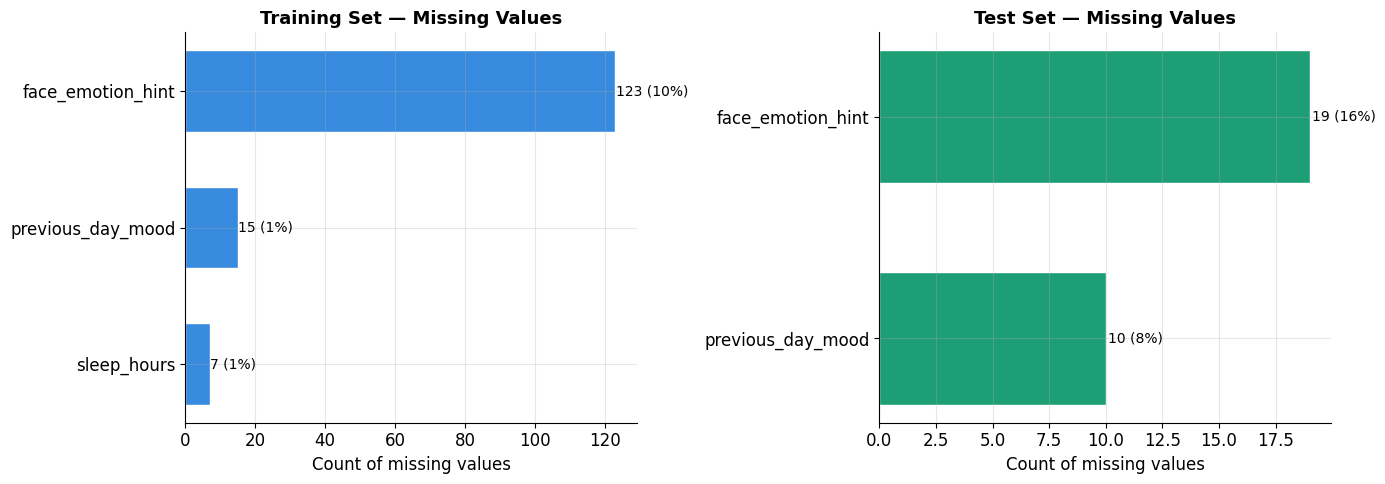


 Plan: Impute numeric NaN with median, categorical NaN with "unknown"


In [14]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title, color in zip(
    axes, [train, test], ['Training Set', 'Test Set'], ['#378ADD', '#1D9E75']
):
    miss = df.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=True)
    if len(miss) == 0:
        ax.text(0.5, 0.5, 'No missing values!', ha='center', va='center',
                fontsize=14, color='green', transform=ax.transAxes)
        ax.set_title(title, fontsize=13, fontweight='bold')
    else:
        bars = ax.barh(miss.index, miss.values, color=color, edgecolor='white', height=0.6)
        ax.set_title(f'{title} — Missing Values', fontsize=13, fontweight='bold')
        ax.set_xlabel('Count of missing values')
        for bar, val in zip(bars, miss.values):
            pct = 100 * val / len(df)
            ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                    f'{val} ({pct:.0f}%)', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Plan: Impute numeric NaN with median, categorical NaN with "unknown"')

## Cell 5 — Emotional State Distribution

> This is your **main target variable** (Part 1 of the assignment). Class imbalance here directly affects model accuracy — if one class has very few samples, your model will ignore it.

In [ ]:

state_counts = train['emotional_state'].value_counts()
state_pct    = (100 * state_counts / len(train)).round(1)

state_df = pd.DataFrame({'count': state_counts, 'percent': state_pct})
print('Emotional State Distribution (Training):')
print(state_df.to_string())
print()
print(f'Total unique states : {len(state_counts)}')
print(f'Most common  : {state_counts.idxmax()} ({state_counts.max()} samples)')
print(f'Rarest       : {state_counts.idxmin()} ({state_counts.min()} samples)')
ratio = state_counts.max() / state_counts.min()
flag  = '  HIGH — use class_weight="balanced" in your model!' if ratio > 3 else ' Acceptable'
print(f'Imbalance ratio : {ratio:.1f}x  {flag}')

Emotional State Distribution (Training):
                 count  percent
emotional_state                
calm               216     18.0
restless           209     17.4
neutral            201     16.8
focused            193     16.1
mixed              191     15.9
overwhelmed        190     15.8

Total unique states : 6
Most common  : calm (216 samples)
Rarest       : overwhelmed (190 samples)
Imbalance ratio : 1.1x   Acceptable


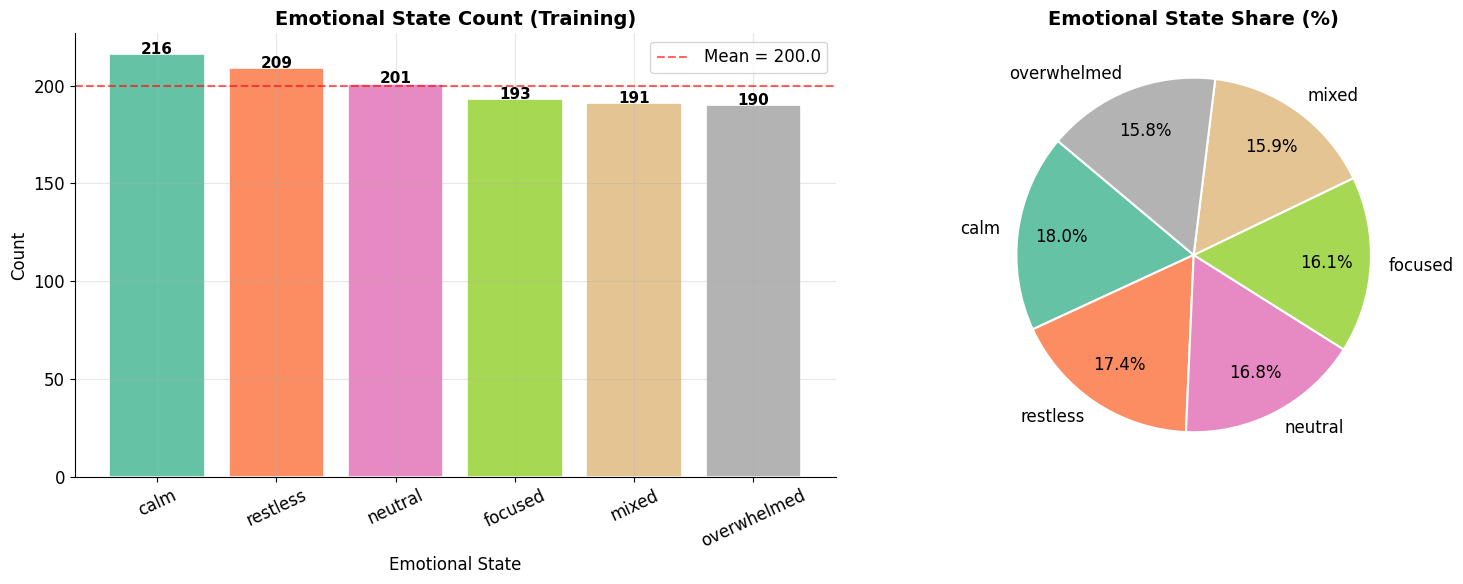

In [17]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.Set2(np.linspace(0, 1, len(state_counts)))
bars   = axes[0].bar(state_counts.index, state_counts.values,
                     color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Emotional State Count (Training)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Emotional State')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=25)
axes[0].axhline(state_counts.mean(), color='red', linestyle='--',
                alpha=0.6, label=f'Mean = {state_counts.mean():.1f}')
for bar, val in zip(bars, state_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', fontweight='bold', fontsize=11)
axes[0].legend()

# Right — pie chart
axes[1].pie(state_counts.values, labels=state_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=140,
            pctdistance=0.75, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Emotional State Share (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_state_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 6 — Intensity Distribution (1–5)

> This is your **second target variable** (Part 2). Intensity is **ordinal** — level 1 < 2 < 3 < 4 < 5. Treat it as ordinal classification, NOT pure regression.

In [18]:

intensity_counts = train['intensity'].value_counts().sort_index()
print('Intensity distribution:')
for level, count in intensity_counts.items():
    pct = 100 * count / len(train)
    bar = '█' * count
    print(f'  Level {level}  |  {count:3d} ({pct:4.1f}%)  {bar}')
print()
print(f'Mean   : {train["intensity"].mean():.2f}')
print(f'Median : {train["intensity"].median():.1f}')
print(f'Std    : {train["intensity"].std():.2f}')

Intensity distribution:
  Level 1  |  226 (18.8%)  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Level 2  |  228 (19.0%)  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Level 3  |  240 (20.0%)  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Level 4  |  277 (23.1%)  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

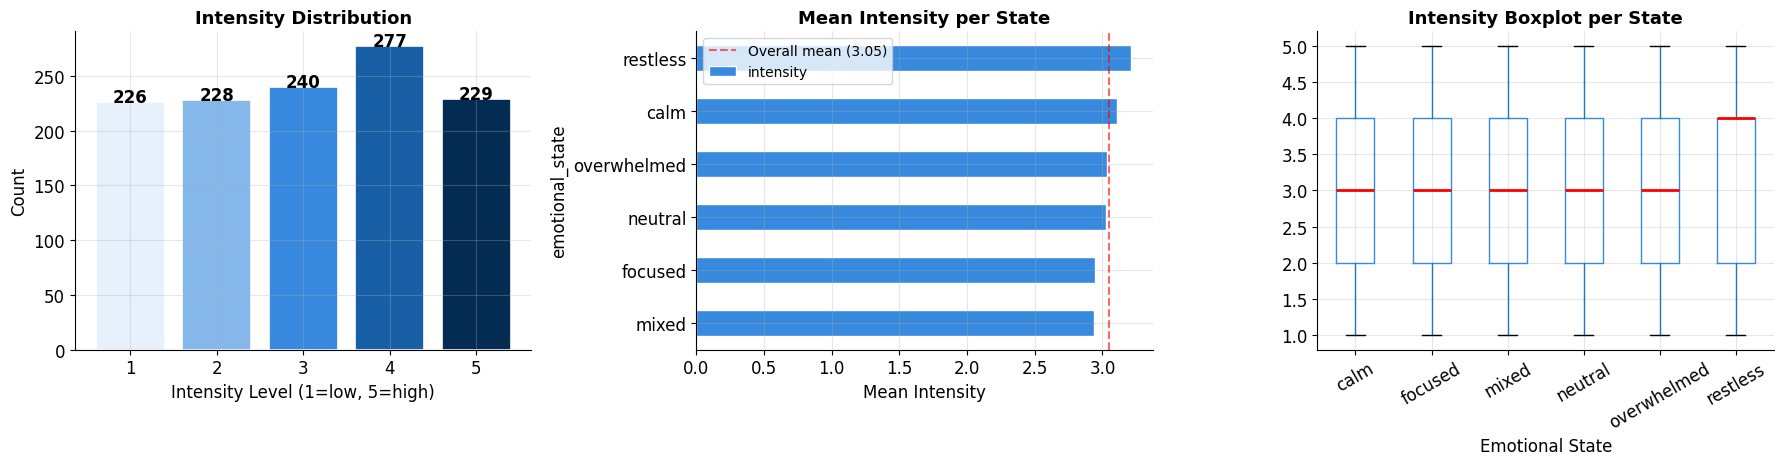

In [19]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


palette = ['#E6F1FB','#85B7EB','#378ADD','#185FA5','#042C53']
axes[0].bar(intensity_counts.index, intensity_counts.values,
            color=palette, edgecolor='white', linewidth=1.2)
axes[0].set_title('Intensity Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Intensity Level (1=low, 5=high)')
axes[0].set_ylabel('Count')
for i, (lvl, cnt) in enumerate(intensity_counts.items()):
    axes[0].text(lvl, cnt + 0.2, str(cnt), ha='center', fontweight='bold')


mean_by_state = train.groupby('emotional_state')['intensity'].mean().sort_values()
mean_by_state.plot(kind='barh', ax=axes[1], color='#378ADD', edgecolor='white')
axes[1].set_title('Mean Intensity per State', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean Intensity')
axes[1].axvline(train['intensity'].mean(), color='red', linestyle='--',
                alpha=0.6, label=f'Overall mean ({train["intensity"].mean():.2f})')
axes[1].legend(fontsize=10)

order = train.groupby('emotional_state')['intensity'].median().sort_values().index
train.boxplot(column='intensity', by='emotional_state', ax=axes[2],
              boxprops=dict(color='#378ADD'),
              medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Intensity Boxplot per State', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Emotional State')
axes[2].tick_params(axis='x', rotation=30)
plt.suptitle('')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_intensity.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 7 — Text Length Analysis

> Short text (≤3 words) gives almost zero signal. These rows will get `uncertain_flag=1` in your predictions. Knowing how many exist helps you plan your model.

In [20]:

def clean_text(text):
    if not isinstance(text, str) or pd.isna(text):
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train['text_clean']  = train['journal_text'].fillna('').apply(clean_text)
test['text_clean']   = test['journal_text'].fillna('').apply(clean_text)
train['text_tokens'] = train['text_clean'].str.split().apply(len)
test['text_tokens']  = test['text_clean'].str.split().apply(len)

print('Text length stats (TRAIN):')
print(train['text_tokens'].describe().round(1).to_string())
print()
print('Text length stats (TEST):')
print(test['text_tokens'].describe().round(1).to_string())
print()

n_short_train = (train['text_tokens'] <= 3).sum()
n_short_test  = (test['text_tokens'] <= 3).sum()
print(f'Short texts ≤3 tokens | TRAIN: {n_short_train} ({100*n_short_train/len(train):.1f}%)')
print(f'Short texts ≤3 tokens | TEST : {n_short_test} ({100*n_short_test/len(test):.1f}%)')

Text length stats (TRAIN):
count    1200.0
mean       11.0
std         5.4
min         2.0
25%         6.0
50%        11.0
75%        14.0
max        34.0

Text length stats (TEST):
count    120.0
mean      12.2
std        5.0
min        2.0
25%       10.8
50%       13.0
75%       15.0
max       21.0

Short texts ≤3 tokens | TRAIN: 119 (9.9%)
Short texts ≤3 tokens | TEST : 17 (14.2%)


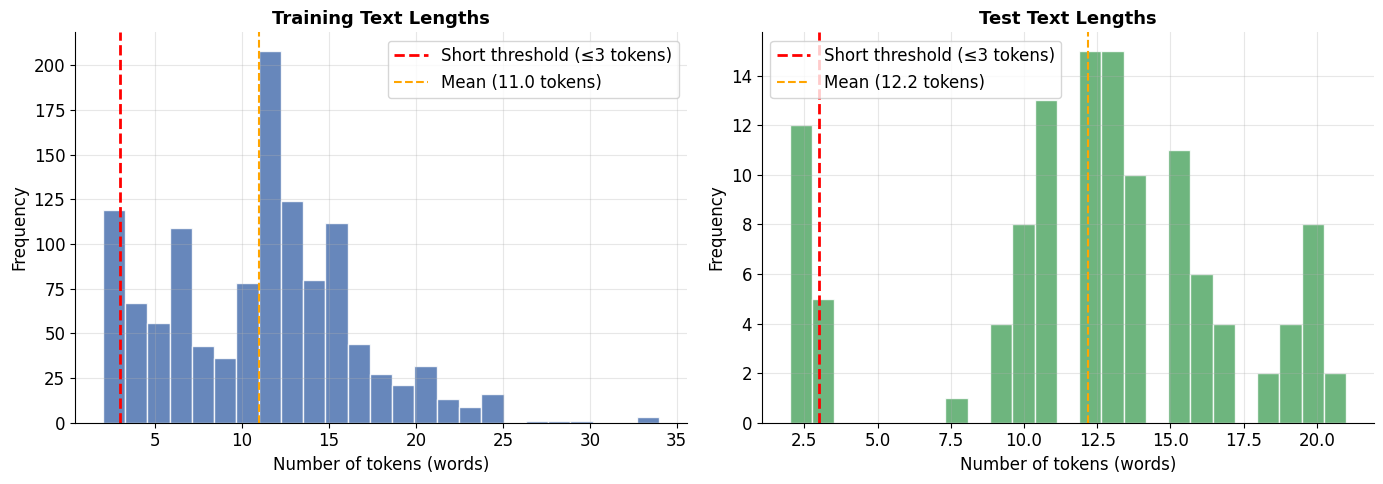

In [21]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title, color in zip(
    axes,
    [train, test],
    ['Training Text Lengths', 'Test Text Lengths'],
    ['#4C72B0', '#55A868']
):
    ax.hist(df['text_tokens'], bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(3, color='red', linestyle='--', linewidth=2,
               label='Short threshold (≤3 tokens)')
    ax.axvline(df['text_tokens'].mean(), color='orange', linestyle='--', linewidth=1.5,
               label=f'Mean ({df["text_tokens"].mean():.1f} tokens)')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of tokens (words)')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_text_length.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:

print('Short texts in TRAINING (≤3 tokens) with their labels:')
short_train = train[train['text_tokens'] <= 3][[
    'id', 'journal_text', 'emotional_state', 'intensity', 'text_tokens'
]].head(15)
short_train

Short texts in TRAINING (≤3 tokens) with their labels:


,id,journal_text,emotional_state,intensity,text_tokens
485,486,kinda calm now,overwhelmed,2,3
486,487,felt heavy,overwhelmed,3,2
488,489,honestly okay session.,calm,1,3
497,498,kinda calm now,focused,5,3
509,510,got distracted again,calm,5,3
523,524,felt heavy,calm,5,2
529,530,it was fine,calm,3,3
539,540,okay session,focused,1,2
549,550,okay session,neutral,1,2
563,564,kinda calm now,overwhelmed,1,3


## Cell 8 — Vague / No-Signal Text Detection

> Some entries say 'ok', 'fine', 'meh' — these are written but carry zero emotional information. Your model should flag these as uncertain.

In [ ]:

EMPTY_WORDS = {'ok', 'okay', 'fine', 'good', 'bad', 'meh',
               'idk', 'nothing', 'same', 'whatever', 'tired'}

def is_vague(text):
    """Returns True if text is noise-only or extremely short."""
    if not isinstance(text, str): return True
    tokens  = clean_text(text).split()
    content = [t for t in tokens if t not in EMPTY_WORDS]
    return len(content) <= 1

train['is_vague'] = train['journal_text'].apply(is_vague)
test['is_vague']  = test['journal_text'].apply(is_vague)

print(f'Vague texts in TRAIN : {train["is_vague"].sum()} ({100*train["is_vague"].mean():.1f}%)')
print(f'Vague texts in TEST  : {test["is_vague"].sum()} ({100*test["is_vague"].mean():.1f}%)')
print()
print('State distribution in VAGUE training texts:')
print(train[train['is_vague']]['emotional_state'].value_counts().to_string())
print()
print('  These rows will get uncertain_flag=1 in predictions')

Vague texts in TRAIN : 20 (1.7%)
Vague texts in TEST  : 4 (3.3%)

State distribution in VAGUE training texts:
emotional_state
focused        6
mixed          4
calm           3
overwhelmed    3
neutral        2
restless       2

⚠️  These rows will get uncertain_flag=1 in predictions


In [25]:

num_cols = ['sleep_hours', 'energy_level', 'stress_level', 'duration_min', 'intensity']
corr = train[num_cols].corr()

print('Correlation matrix:')
print(corr.round(2).to_string())
print()

pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i,j]))
pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print('Strongest correlations:')
for a, b, c in pairs[:5]:
    direction = '↑ positive' if c > 0 else '↓ negative'
    print(f'  {a} ↔ {b} : r={c:.3f}  {direction}')

Correlation matrix:
              sleep_hours  energy_level  stress_level  duration_min  intensity
sleep_hours          1.00         -0.01          0.02         -0.03      -0.03
energy_level        -0.01          1.00          0.01          0.02      -0.01
stress_level         0.02          0.01          1.00         -0.07       0.00
duration_min        -0.03          0.02         -0.07          1.00      -0.02
intensity           -0.03         -0.01          0.00         -0.02       1.00

Strongest correlations:
  stress_level ↔ duration_min : r=-0.071  ↓ negative
  sleep_hours ↔ intensity : r=-0.034  ↓ negative
  sleep_hours ↔ duration_min : r=-0.026  ↓ negative
  energy_level ↔ duration_min : r=0.020  ↑ positive
  sleep_hours ↔ stress_level : r=0.018  ↑ positive


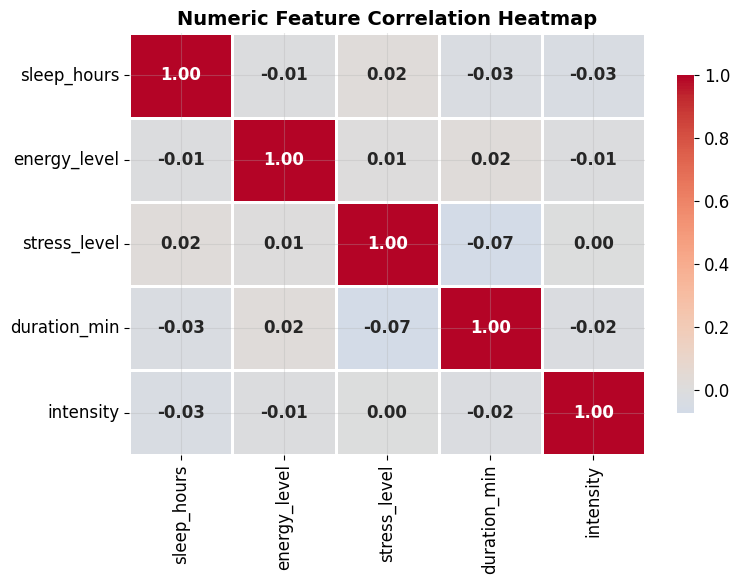

In [28]:

fig, ax = plt.subplots(figsize=(8, 6))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # upper triangle
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.8, ax=ax,
    annot_kws={'size': 12, 'weight': 'bold'},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Numeric Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 10 — Stress vs Energy Scatter Plot

> This is the most important chart for understanding emotional state clusters. Each emotional state should cluster in different quadrants of this 2D space.

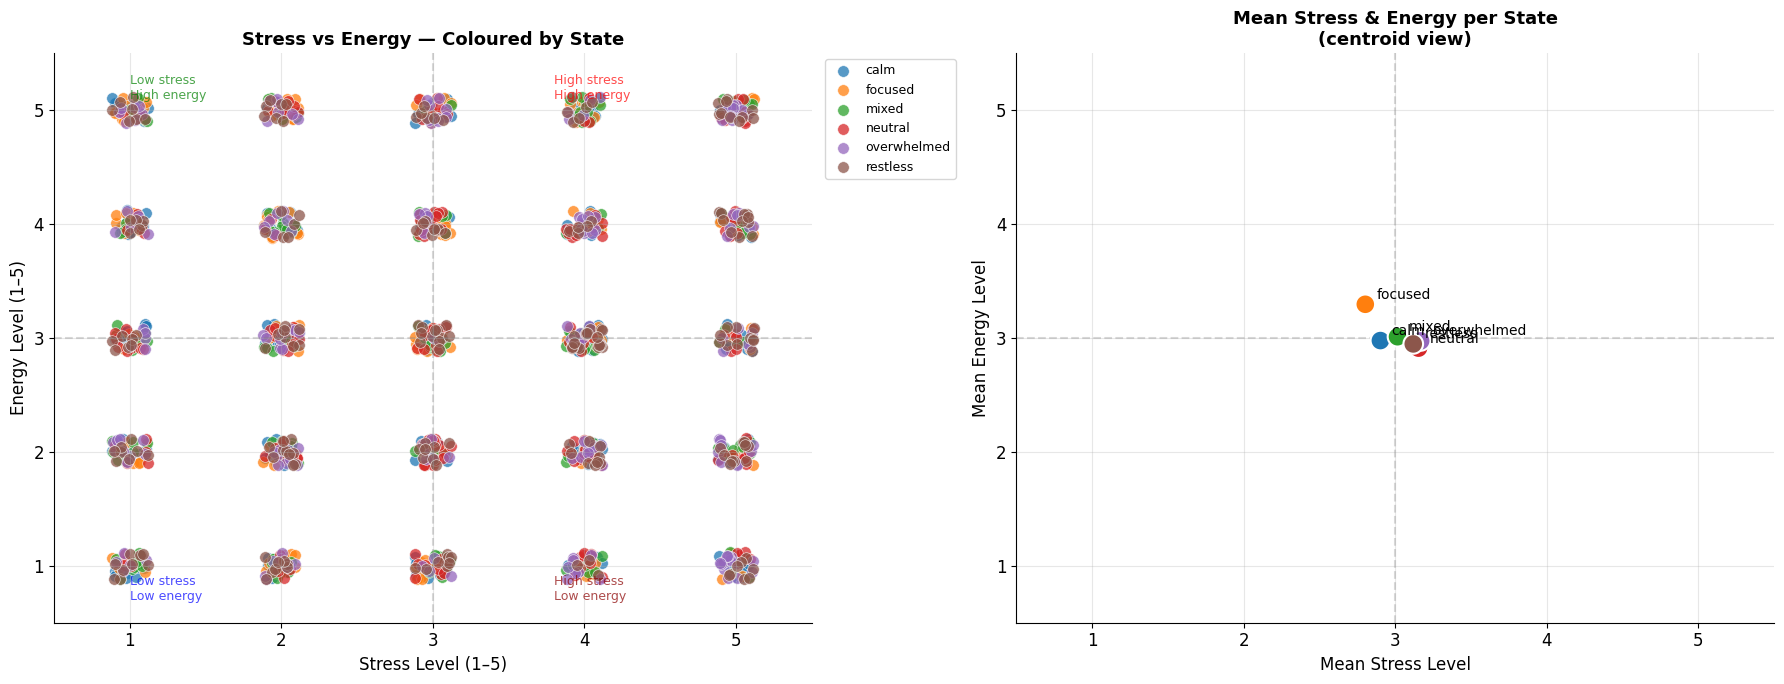

In [ ]:

states  = sorted(train['emotional_state'].unique())
palette = sns.color_palette('tab10', len(states))
cmap    = dict(zip(states, palette))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))


for state in states:
    sub = train[train['emotional_state'] == state]
    axes[0].scatter(
        sub['stress_level'] + np.random.uniform(-0.12, 0.12, len(sub)),
        sub['energy_level'] + np.random.uniform(-0.12, 0.12, len(sub)),
        label=state, s=70, alpha=0.75,
        color=cmap[state], edgecolors='white', linewidths=0.5
    )

axes[0].set_xlabel('Stress Level (1–5)', fontsize=12)
axes[0].set_ylabel('Energy Level (1–5)', fontsize=12)
axes[0].set_title('Stress vs Energy — Coloured by State', fontsize=13, fontweight='bold')
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
axes[0].set_xlim(0.5, 5.5)
axes[0].set_ylim(0.5, 5.5)
axes[0].axvline(3, color='gray', linestyle='--', alpha=0.3)
axes[0].axhline(3, color='gray', linestyle='--', alpha=0.3)
axes[0].text(1.0, 5.1, 'Low stress\nHigh energy', fontsize=9, color='green', alpha=0.7)
axes[0].text(3.8, 5.1, 'High stress\nHigh energy', fontsize=9, color='red', alpha=0.7)
axes[0].text(1.0, 0.7, 'Low stress\nLow energy', fontsize=9, color='blue', alpha=0.7)
axes[0].text(3.8, 0.7, 'High stress\nLow energy', fontsize=9, color='darkred', alpha=0.7)

# Right — mean stress & energy per state
mean_vals = train.groupby('emotional_state')[['stress_level','energy_level']].mean()
x = mean_vals['stress_level']
y = mean_vals['energy_level']
colors_scatter = [cmap[s] for s in mean_vals.index]
axes[1].scatter(x, y, s=200, c=colors_scatter, edgecolors='white', linewidths=1.5, zorder=3)
for state, (sx, sy) in zip(mean_vals.index, zip(x, y)):
    axes[1].annotate(state, (sx, sy), textcoords='offset points',
                     xytext=(8, 4), fontsize=10)
axes[1].set_xlabel('Mean Stress Level', fontsize=12)
axes[1].set_ylabel('Mean Energy Level', fontsize=12)
axes[1].set_title('Mean Stress & Energy per State\n(centroid view)', fontsize=13, fontweight='bold')
axes[1].axvline(3, color='gray', linestyle='--', alpha=0.3)
axes[1].axhline(3, color='gray', linestyle='--', alpha=0.3)
axes[1].set_xlim(0.5, 5.5)
axes[1].set_ylim(0.5, 5.5)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_stress_vs_energy.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 11 — Time of Day Breakdown

In [29]:
# Time of day counts and state cross-tab
tod_counts = train['time_of_day'].value_counts()
print('Session count by time of day:')
print(tod_counts.to_string())
print()
print('Cross-tab — Time of day × Emotional state:')
tod_state = pd.crosstab(train['time_of_day'], train['emotional_state'])
tod_state

Session count by time of day:
time_of_day
afternoon        319
morning          302
night            286
evening          268
early_morning     25

Cross-tab — Time of day × Emotional state:


emotional_state,calm,focused,mixed,neutral,overwhelmed,restless
time_of_day,,,,,,
afternoon,51,51,48,54,60,55
early_morning,5,5,3,2,3,7
evening,52,40,54,41,37,44
morning,59,47,45,57,43,51
night,49,50,41,47,47,52


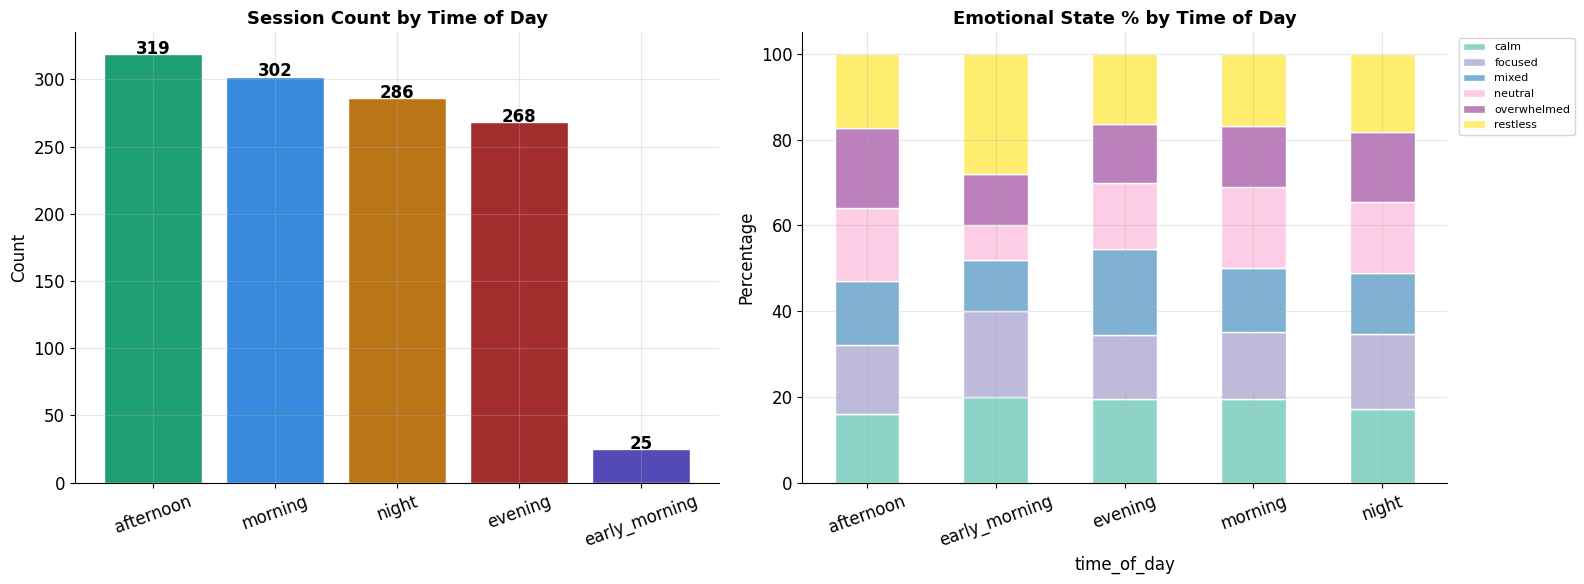

In [30]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_tod = ['#1D9E75','#378ADD','#BA7517','#A32D2D','#534AB7']
tod_counts_sorted = train['time_of_day'].value_counts()
bars = axes[0].bar(tod_counts_sorted.index, tod_counts_sorted.values,
                   color=colors_tod[:len(tod_counts_sorted)], edgecolor='white')
axes[0].set_title('Session Count by Time of Day', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, tod_counts_sorted.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(val), ha='center', fontweight='bold')


tod_state_norm = pd.crosstab(
    train['time_of_day'], train['emotional_state'], normalize='index'
) * 100
tod_state_norm.plot(kind='bar', stacked=True, ax=axes[1],
                    colormap='Set3', edgecolor='white')
axes[1].set_title('Emotional State % by Time of Day', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_time_of_day.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 12 — Ambience Type Breakdown

In [32]:

amb_counts  = train['ambience_type'].value_counts()
amb_intens  = train.groupby('ambience_type')['intensity'].mean().sort_values(ascending=False)
amb_state   = pd.crosstab(train['ambience_type'], train['emotional_state'],
                           normalize='index').round(2) * 100

print('Ambience count:')
print(amb_counts.to_string())
print()
print('Mean intensity per ambience:')
print(amb_intens.round(2).to_string())
print()
print('State % per ambience (top 3 states):')
print(amb_state.to_string())

Ambience count:
ambience_type
ocean       268
mountain    252
forest      231
cafe        229
rain        220

Mean intensity per ambience:
ambience_type
cafe        3.28
ocean       3.06
mountain    3.00
forest      2.96
rain        2.93

State % per ambience (top 3 states):
emotional_state  calm  focused  mixed  neutral  overwhelmed  restless
ambience_type                                                        
cafe             16.0     24.0   13.0     15.0         17.0      16.0
forest           19.0     13.0   19.0     15.0         11.0      22.0
mountain         20.0     12.0   18.0     15.0         16.0      18.0
ocean            17.0     16.0   16.0     19.0         17.0      15.0
rain             18.0     16.0   12.0     20.0         18.0      16.0


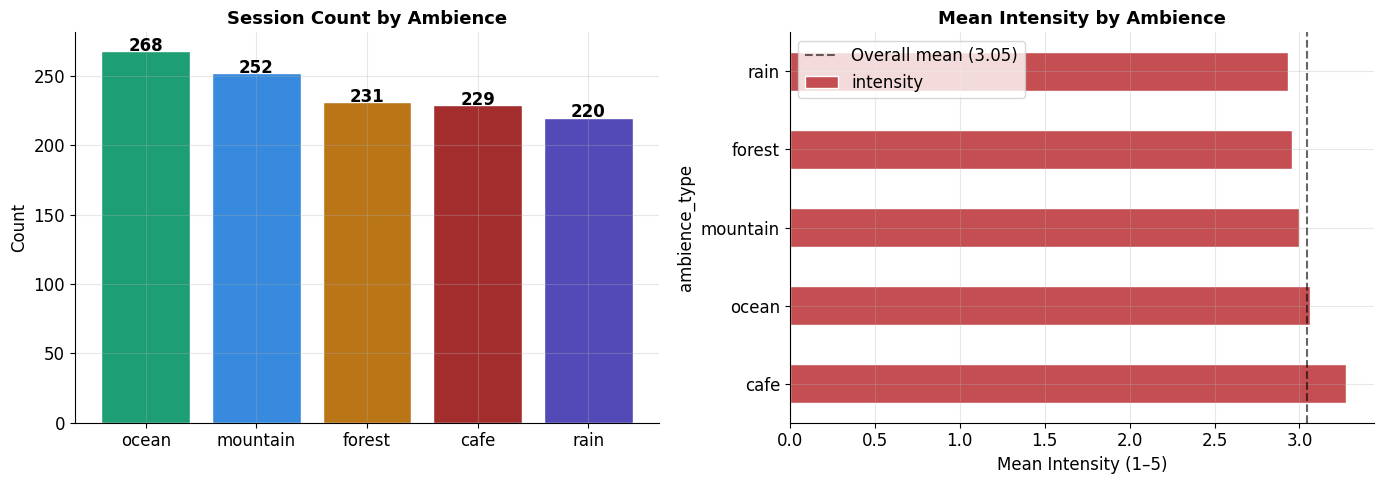

In [33]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

amb_colors = ['#1D9E75','#378ADD','#BA7517','#A32D2D','#534AB7']
bars = axes[0].bar(amb_counts.index, amb_counts.values,
                   color=amb_colors[:len(amb_counts)], edgecolor='white')
axes[0].set_title('Session Count by Ambience', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, amb_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(val), ha='center', fontweight='bold')

amb_intens.plot(kind='barh', ax=axes[1], color='#C44E52', edgecolor='white')
axes[1].set_title('Mean Intensity by Ambience', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean Intensity (1–5)')
axes[1].axvline(train['intensity'].mean(), color='black', linestyle='--',
                alpha=0.6, label=f'Overall mean ({train["intensity"].mean():.2f})')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_ambience.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 13 — Feature Boxplots per Emotional State

> Boxplots show HOW DIFFERENT each state is for a given feature. Wide separation between boxes = the feature is a strong predictor. Overlapping boxes = the feature struggles to separate classes.

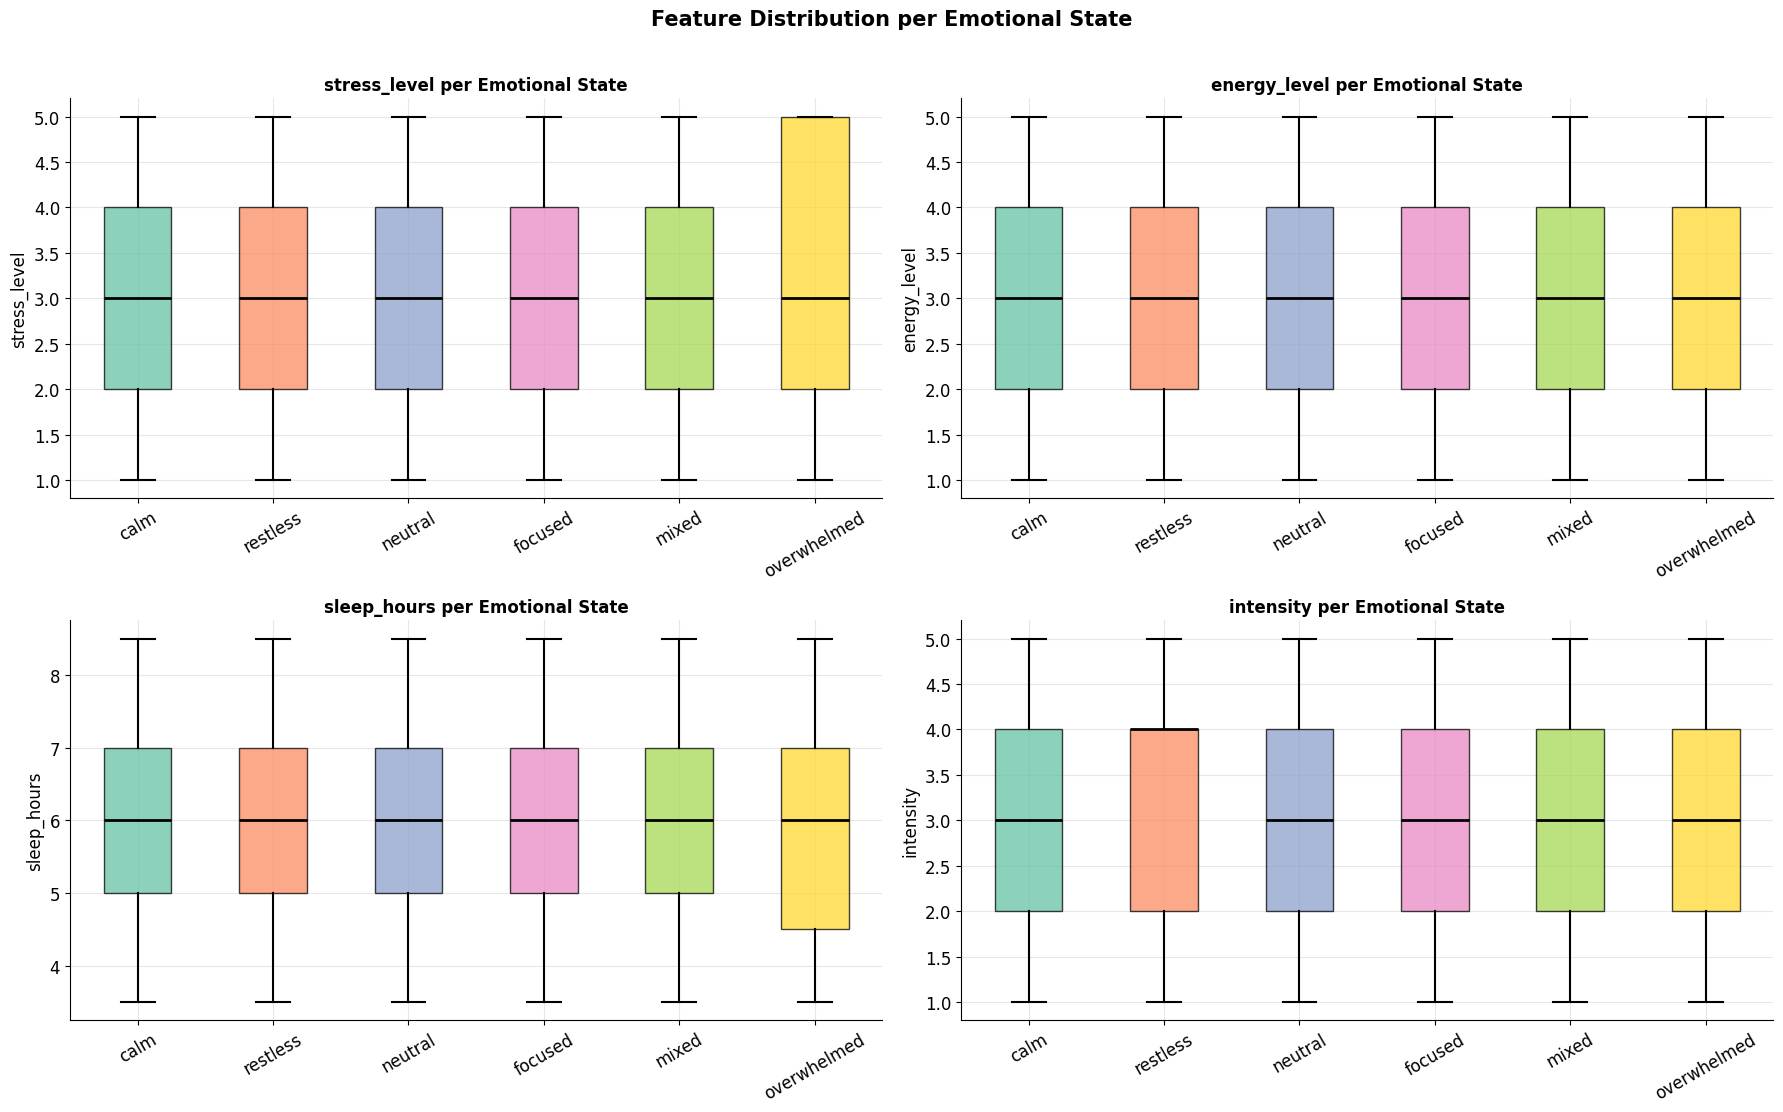

In [35]:

features = ['stress_level', 'energy_level', 'sleep_hours', 'intensity']
state_order = train['emotional_state'].value_counts().index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
axes = axes.flatten()

palette_box = sns.color_palette('Set2', len(state_order))

for ax, feat in zip(axes, features):
    data_groups = []
    labels      = []
    colors_box  = []
    for i, state in enumerate(state_order):
        vals = train[train['emotional_state'] == state][feat].dropna().values
        if len(vals) > 0:
            data_groups.append(vals)
            labels.append(state)
            colors_box.append(palette_box[i % len(palette_box)])

    bp = ax.boxplot(data_groups, labels=labels, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_title(f'{feat} per Emotional State', fontsize=12, fontweight='bold')
    ax.set_ylabel(feat)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Feature Distribution per Emotional State', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 14 — Reflection Quality Analysis

> `reflection_quality` tells you how reliable each label is. **vague** and **conflicted** rows are harder to learn from — the model should be less confident on these.

In [36]:

rq_train = train['reflection_quality'].value_counts()
rq_test  = test['reflection_quality'].value_counts()

print('Reflection quality — TRAIN:')
print(rq_train.to_string())
print()
print('Reflection quality — TEST:')
print(rq_test.to_string())
print()


print('Mean intensity per reflection quality:')
print(train.groupby('reflection_quality')['intensity'].mean().round(2).to_string())

Reflection quality — TRAIN:
reflection_quality
clear         411
vague         400
conflicted    389

Reflection quality — TEST:
reflection_quality
vague         42
clear         39
conflicted    39

Mean intensity per reflection quality:
reflection_quality
clear         2.99
conflicted    3.18
vague         2.97


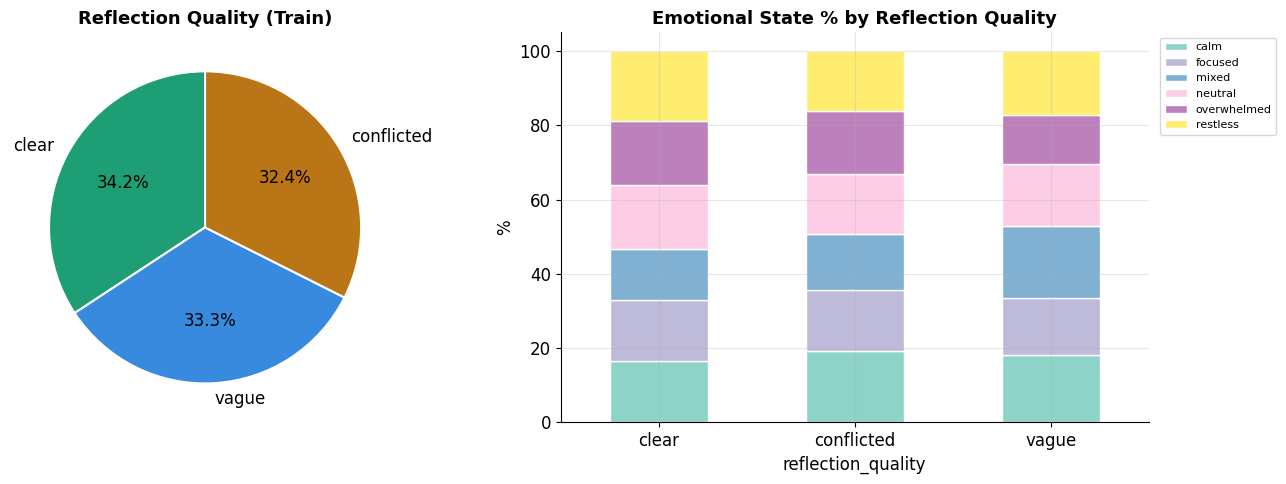

In [37]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


rq_colors = ['#1D9E75','#378ADD','#BA7517']
axes[0].pie(rq_train.values, labels=rq_train.index,
            autopct='%1.1f%%', colors=rq_colors,
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[0].set_title('Reflection Quality (Train)', fontsize=13, fontweight='bold')


rq_state = pd.crosstab(train['reflection_quality'], train['emotional_state'],
                        normalize='index') * 100
rq_state.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set3', edgecolor='white')
axes[1].set_title('Emotional State % by Reflection Quality', fontsize=13, fontweight='bold')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/10_reflection_quality.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 15 — Previous Day Mood Analysis

In [38]:

prev_counts = train['previous_day_mood'].value_counts()
print('Previous day mood (train):')
print(prev_counts.to_string())
print(f'\nNaN count: {train["previous_day_mood"].isna().sum()}')
print()
print('Does previous mood predict current state?')
pd.crosstab(train['previous_day_mood'].fillna('unknown'),
            train['emotional_state'])

Previous day mood (train):
previous_day_mood
mixed          213
restless       208
neutral        203
overwhelmed    202
calm           182
focused        177

NaN count: 15

Does previous mood predict current state?


emotional_state,calm,focused,mixed,neutral,overwhelmed,restless
previous_day_mood,,,,,,
calm,36,31,31,28,22,34
focused,38,27,26,32,27,27
mixed,27,43,37,40,30,36
neutral,39,29,36,28,41,30
overwhelmed,41,37,23,30,28,43
restless,33,24,34,43,38,36
unknown,2,2,4,0,4,3


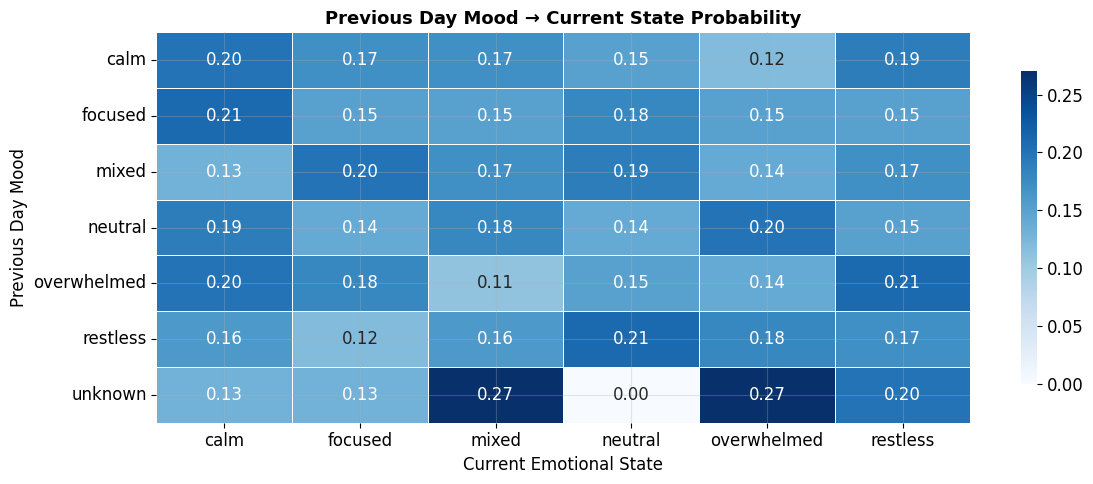

💡 High values on diagonal = previous mood strongly predicts current state


In [39]:

cross = pd.crosstab(train['previous_day_mood'].fillna('unknown'),
                    train['emotional_state'], normalize='index').round(2)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(cross, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Previous Day Mood → Current State Probability', fontsize=13, fontweight='bold')
ax.set_xlabel('Current Emotional State')
ax.set_ylabel('Previous Day Mood')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/11_prev_mood.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 16 — Sleep Hours Deep Dive

> Sleep is one of the most important metadata signals. Low sleep strongly correlates with overwhelmed/restless states.

In [40]:

sleep_by_state = train.groupby('emotional_state')['sleep_hours'].agg(
    ['mean','median','min','max','count']
).round(2).sort_values('mean')

print('Sleep hours per emotional state:')
sleep_by_state

Sleep hours per emotional state:


,mean,median,min,max,count
emotional_state,,,,,
overwhelmed,5.84,6.0,3.5,8.5,189
restless,5.86,6.0,3.5,8.5,209
mixed,6.02,6.0,3.5,8.5,191
focused,6.04,6.0,3.5,8.5,189
neutral,6.07,6.0,3.5,8.5,201
calm,6.10,6.0,3.5,8.5,214


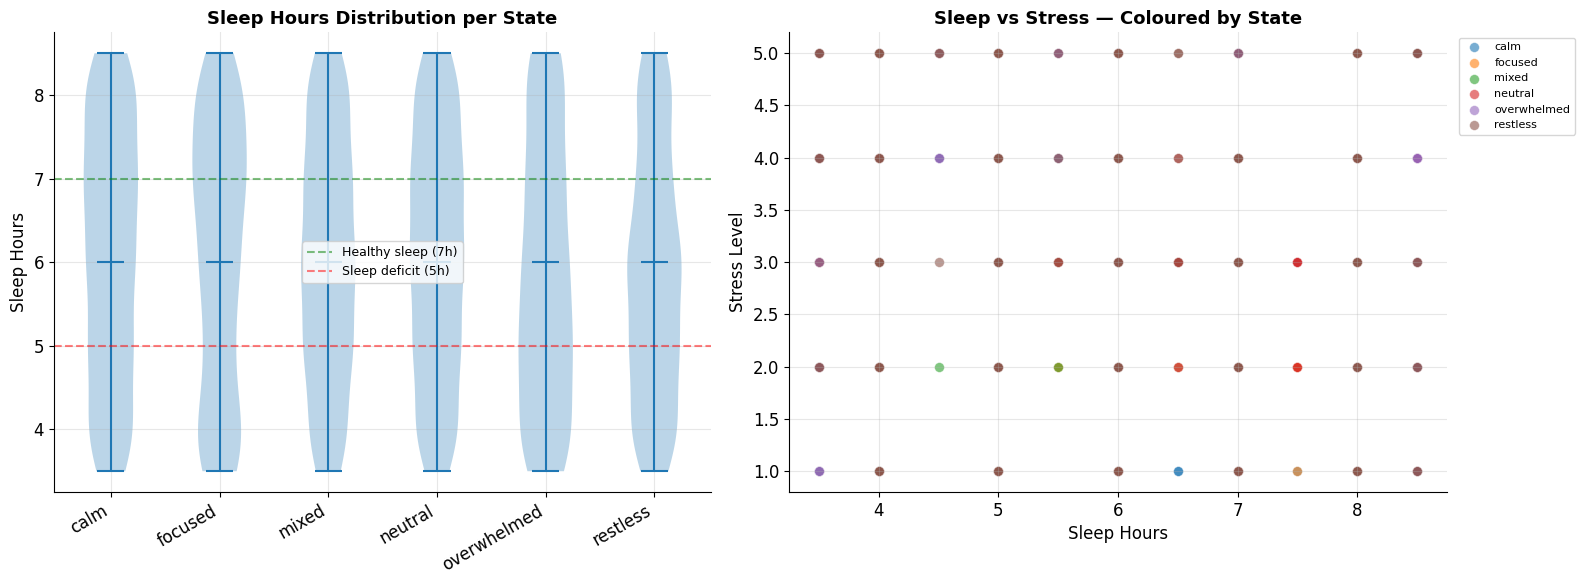

In [41]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

states_with_sleep = train.dropna(subset=['sleep_hours'])
state_order_sleep = states_with_sleep.groupby('emotional_state')['sleep_hours'].median().sort_values().index
data_violin = [states_with_sleep[states_with_sleep['emotional_state'] == s]['sleep_hours'].values
               for s in state_order_sleep]
vp = axes[0].violinplot(data_violin, showmedians=True, showmeans=False)
axes[0].set_xticks(range(1, len(state_order_sleep)+1))
axes[0].set_xticklabels(state_order_sleep, rotation=30, ha='right')
axes[0].set_title('Sleep Hours Distribution per State', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sleep Hours')
axes[0].axhline(7, color='green', linestyle='--', alpha=0.5, label='Healthy sleep (7h)')
axes[0].axhline(5, color='red',   linestyle='--', alpha=0.5, label='Sleep deficit (5h)')
axes[0].legend(fontsize=9)

for state in sorted(train['emotional_state'].unique()):
    sub = train[train['emotional_state'] == state].dropna(subset=['sleep_hours'])
    axes[1].scatter(sub['sleep_hours'], sub['stress_level'],
                    label=state, alpha=0.6, s=50, edgecolors='white', linewidths=0.5)
axes[1].set_xlabel('Sleep Hours')
axes[1].set_ylabel('Stress Level')
axes[1].set_title('Sleep vs Stress — Coloured by State', fontsize=13, fontweight='bold')
axes[1].legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/12_sleep_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 17 — Word Frequency in Journal Text

> Which words appear most in each emotional state? This directly tells you what TF-IDF will learn. If 'overwhelmed' and 'flooded' appear only in the 'overwhelmed' class, TF-IDF will be a strong signal.

In [42]:

from collections import Counter

STOPWORDS = {
    'i', 'the', 'a', 'and', 'to', 'in', 'of', 'my', 'it', 'me',
    'was', 'is', 'but', 'still', 'feel', 'felt', 'after', 'the',
    'like', 'that', 'with', 'not', 'just', 'for', 'this', 'bit',
    'some', 'more', 'can', 'at', 'on', 'during', 'session', 'though'
}

word_freq_by_state = {}
for state in sorted(train['emotional_state'].unique()):
    texts  = train[train['emotional_state'] == state]['text_clean'].tolist()
    all_words = []
    for t in texts:
        words = [w for w in t.split() if len(w) > 3 and w not in STOPWORDS]
        all_words.extend(words)
    word_freq_by_state[state] = Counter(all_words).most_common(8)

print('Top 8 words per emotional state (excluding stopwords):')
print()
for state, words in word_freq_by_state.items():
    top = ', '.join([f'{w}({c})' for w, c in words])
    print(f'  {state:<15} : {top}')

Top 8 words per emotional state (excluding stopwords):

  calm            : lighter(40), mind(35), less(23), breathing(23), slowed(22), quiet(20), peaceful(18), honestly(17)
  focused         : honestly(27), first(24), helped(21), organized(21), started(20), better(20), concentrate(17), plan(17)
  mixed           : better(33), little(29), honestly(28), distracted(27), helped(27), first(27), part(26), calmer(24)
  neutral         : moment(30), nothing(28), normal(26), didn(22), notice(21), first(21), changed(20), honestly(20)
  overwhelmed     : heavy(28), much(27), mentally(22), drained(22), didn(21), first(21), honestly(19), everything(18)
  restless        : kept(43), tasks(28), thinking(26), honestly(26), even(23), about(22), mind(21), helped(20)


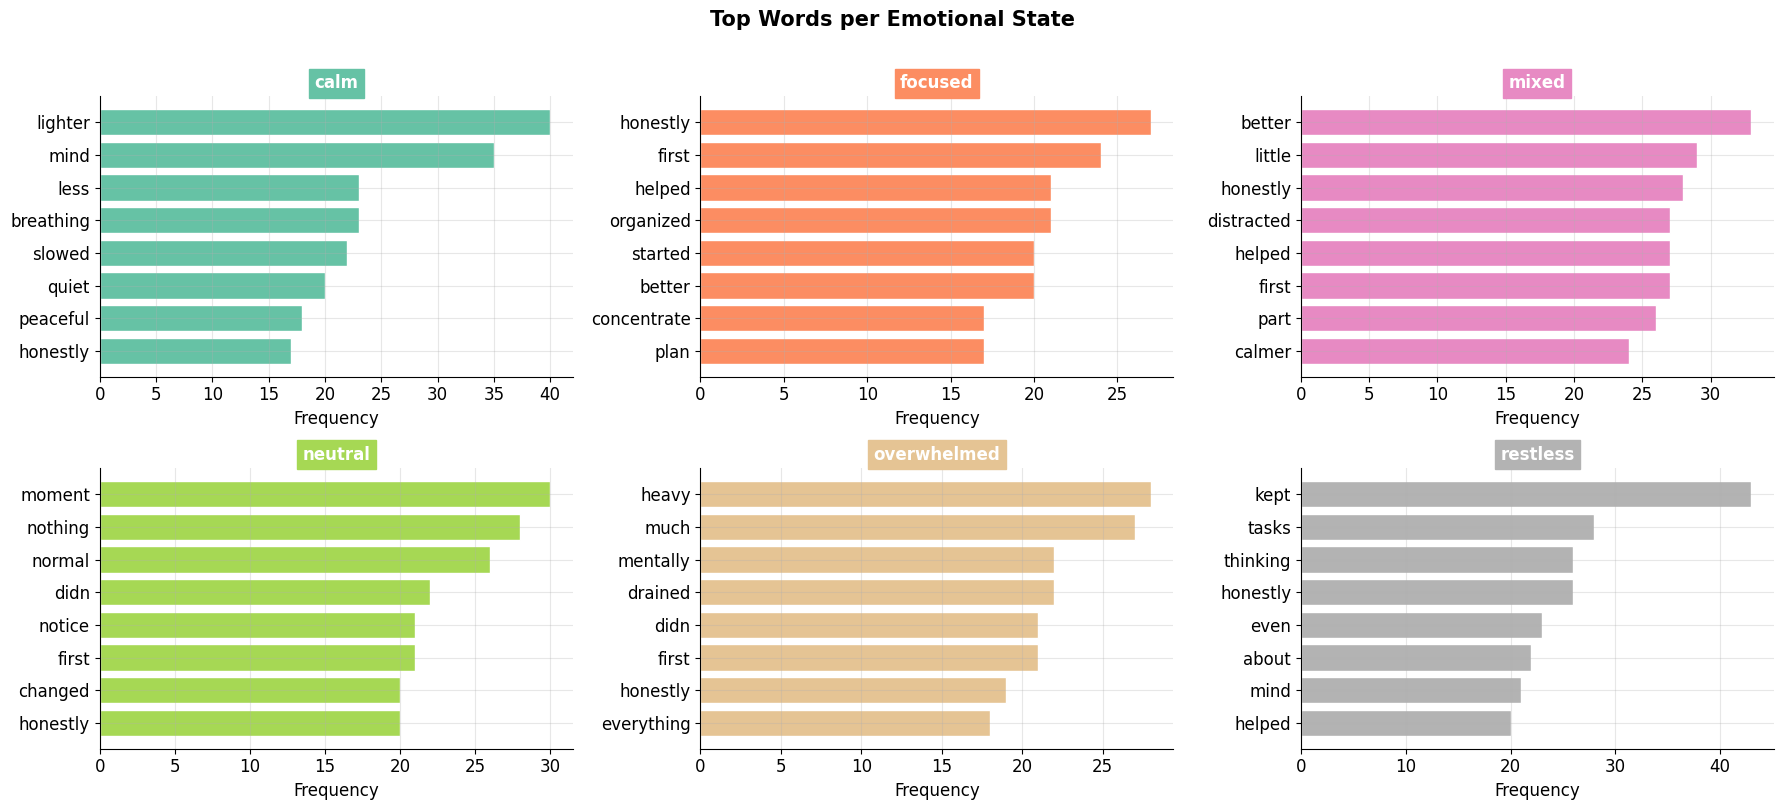

In [43]:

states_list = sorted(train['emotional_state'].unique())
ncols = 3
nrows = -(-len(states_list) // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*4))
axes = axes.flatten()

bar_colors = plt.cm.Set2(np.linspace(0, 1, len(states_list)))

for i, state in enumerate(states_list):
    words, counts = zip(*word_freq_by_state[state]) if word_freq_by_state[state] else ([], [])
    axes[i].barh(list(words)[::-1], list(counts)[::-1],
                 color=bar_colors[i], edgecolor='white')
    axes[i].set_title(f'{state}', fontsize=12, fontweight='bold',
                      color='white', backgroundcolor=bar_colors[i])
    axes[i].set_xlabel('Frequency')

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top Words per Emotional State', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/13_word_frequency.png', dpi=150, bbox_inches='tight')
plt.show()